# **09 · B2C 진단 규칙 설계 — 11개 응답으로 웹데모가 파이프라인과 같은 판정을 내리게 한다**

### **"입력 = cred 3문항(1~5) + 8매체 이용여부 체크. 판정 = pooled 기준선(z 파라미터·스케일·중앙값 임계)을 상수로 이식한 4사분면 규칙 — 사양(JSON)대로 재계산한 판정이 파이프라인 `persona_quadrant`와 90,996행 전수 일치함을 입증하고, 그 사양 파일을 웹데모의 SSOT로 export한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = B2C 자가진단(웹데모)의 입력·판정·처방 사양 · 방법 = **사양 상수 도출 + 전수 재판정 일치 검증 + JSON export**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **보고·전개(B2C 사양)** · CRISP-DM **P6(Deployment)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 웹데모 입력은 왜 이 **11개 문항**(cred3 + 8매체)으로 충분한가 — 무엇을 버렸고 왜 버려도 되는가?
> **Q2.** 판정 로직을 파이썬 없이(정적 웹) 재현하려면 어떤 **상수**가 필요한가 — 그 상수로 재계산한 판정은 파이프라인과 일치하는가?
> **Q3.** 유형별 진단 메시지·처방은 어느 검증된 근거에 얹히는가?

## **이 노트북의 위상 — 웹데모(P6-C)의 사양 SSOT**

`04`가 유형화 방법을, `08`이 유형의 내용을 확정했다면, 09는 그것을 **제품 사양**으로 번역한다. 산출물은 두 개다: ① 이 노트북 자체(판정 로직의 입증), ② [`web/diagnosis-spec.json`](../web/diagnosis-spec.json) — Next.js 웹데모가 import할 상수 파일. 웹데모 구현(P6-C)은 이 사양을 소비만 하고 로직을 재정의하지 않는다.

- **로직 SSOT(thin import)**: `hp._trust_score_respondent`·`nf._scale_1_100`·`persona_quadrant` — 사양 상수는 이 함수들의 파라미터를 **추출**한 것(§2), 검증은 상수 경로와 함수 경로의 전수 대조(§4).
- **관련**: `05` DB②(자격) · `08`(처방 근거) · manuscript 7.2절(B2C 제안).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 입력 최소화 — **Decision Box ①** | — |
| 2 | [실행] 판정 상수 도출(z 파라미터·스케일·임계) | 사양 상수 |
| 3 | [실행] 처방 매핑 — 유형 → 메시지(검증 근거 연결) | 처방표 |
| 4 | [입증] 전수 재판정 — 상수 경로 ≡ 함수 경로 + [시각화] | 일치율 100% |
| 5 | [실행] 사양 JSON export + 가상 사용자 데모 | spec 파일 |
| 6 | [입증] 검증 셀 | PASS |
| 7 | [실행] v1.1 분위수/CDF — 상대 위치 lookup | baseline |
| 8 | [실행] v1.1 유형 프로파일 카드(08 재검증) | profiles |
| 9 | [실행] v1.1 경계 밴드(1,125 전수 입증) | boundary_band |
| 10 | [입증] v1.1 검증 + 재export | PASS |
| 11 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import json
import harmonize as hz
import health_index_panel as hp
import news_health_features as nf

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
CORE3 = hp.CORE3
T_resp = hp._trust_score_respondent(panel)                          # 파이프라인 경로(SSOT)
D_raw = pd.to_numeric(panel["richness_fixed8"], errors="coerce")
D_resp = nf._scale_1_100(D_raw)
persona_ref = nf.persona_quadrant(T_resp, D_resp)                   # 기준 판정
print(f"패널 {len(panel):,}행 · 기준 판정(persona_quadrant) 유효 {persona_ref.notna().sum():,}명")

패널 90,996행 · 기준 판정(persona_quadrant) 유효 90,996명


## **1. [전제] 입력 최소화 — 11문항의 근거**

### **Decision Box ① — 자가진단 입력: 전체 배터리 vs 최소 문항**

**기준: 웹 자가진단의 응답 부담(이탈률)과 판정 충실도의 균형.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 원조사 배터리 전체 | 신뢰 배터리 6문항 + 매체 상세(일수·빈도) | ❌ 판정에 쓰이지 않는 문항(press_free 등 — `02`·`18`에서 배제)까지 묻는 것은 응답 부담만 증가 |
| (b) 축약 프록시(예: 신뢰 1문항) | 초경량 입력 | ❌ 단일 문항은 측정오차 통제 불가(`17` DB①) — 파이프라인과 다른 판정 로직이 되어 "같은 잣대" 주장 상실 |
| (c) **판정에 실제 쓰이는 11문항** | cred3(공정·전문·정확, 1~5) + 고정풀 8매체 이용여부 | ✅ **채택** — `persona_quadrant`의 입력이 정확히 이것뿐. 파이프라인과 **동일 로직·동일 기준선**의 판정이 가능(§4에서 전수 입증) |

**버린 것과 그 근거**: press_free(별개 차원, `18`), 신설매체(고정풀 밖 — 판정엔 미사용, 처방 문구에서만 언급), 일수·빈도(이진화가 정렬 최소공배수, `06` R3).

## **2. [실행] 판정 상수 도출 — 웹이 알아야 하는 전부**

`_trust_score_respondent`는 pooled 통계(각 문항의 평균·표준편차, z평균의 min·max)에, `_scale_1_100`은 관측 min·max에, 임계는 pooled 중앙값에 의존한다 — 이 값들을 상수로 추출하면 웹은 파이썬 없이 같은 판정을 재현한다. 다양성 스케일은 richness 관측 범위(0~8)의 선형 환산이라 닫힌 식이 된다.

In [2]:
sub = panel[CORE3].apply(pd.to_numeric, errors="coerce")
item_mean = sub.mean()
item_std = sub.std(ddof=0)
z = (sub - item_mean) / item_std
raw = z.mean(axis=1)

SPEC = {
    "version": "1.0 (P6-B-5, notebooks/09)",
    "inputs": {
        "cred_items": {c: {"label": lab, "scale": [1, 5]}
                       for c, lab in zip(CORE3, ["우리나라 언론은 공정하다",
                                                  "우리나라 언론은 전문적이다",
                                                  "우리나라 언론은 정확하다"])},
        "media_items": {m: lab for m, lab in zip(hz.FIXED_POOL8,
                        ["종이신문", "잡지", "TV", "라디오", "인터넷 뉴스",
                         "메신저 뉴스", "SNS 뉴스", "온라인 동영상 뉴스"])},
    },
    # 상수는 전체 정밀도로 저장 — 반올림하면 임계 경계 응답자의 판정이 뒤집힐 수 있음
    "trust": {
        "item_mean": {c: float(item_mean[c]) for c in CORE3},
        "item_std": {c: float(item_std[c]) for c in CORE3},
        "raw_min": float(raw.min()),
        "raw_max": float(raw.max()),
        "threshold_1_100": float(T_resp.median()),
    },
    "diversity": {
        "richness_min": float(D_raw.min()), "richness_max": float(D_raw.max()),
        "threshold_1_100": float(D_resp.median()),
    },
    "quadrant_labels": {"TT": "건강한 소비자", "TF": "신뢰편향형",
                        "FT": "비판적 탐색형", "FF": "이중취약형"},
}
print(json.dumps({k: SPEC[k] for k in ["trust", "diversity"]}, ensure_ascii=False, indent=2))

{
  "trust": {
    "item_mean": {
      "cred_fair": 3.047573519715152,
      "cred_professional": 3.3661149940656734,
      "cred_accurate": 3.17488680821135
    },
    "item_std": {
      "cred_fair": 0.8832269417805774,
      "cred_professional": 0.9129544655792073,
      "cred_accurate": 0.9141632462476058
    },
    "raw_min": -2.429700017111702,
    "raw_max": 1.9989043112762304,
    "threshold_1_100": 58.662025409389585
  },
  "diversity": {
    "richness_min": 0.0,
    "richness_max": 8.0,
    "threshold_1_100": 25.75
  }
}


## **3. [실행] 처방 매핑 — 문구 하나하나가 검증된 셀에 얹힌다**

진단 메시지의 원칙: **검증된 방향만 말한다**(`05` DB②). 처방의 근거는 `08`의 프로파일 assert — "저다양 유형은 TV 편중·신설매체 0" — 이고, 절대 수치(구성비 %)는 쓰지 않는다.

In [3]:
RX = pd.DataFrame([
    ("건강한 소비자", "신뢰·다양성 모두 상위 절반", "현 레퍼토리 유지 + 출처 교차확인 습관 소개", "05 §2(NCHI 최고 유형)"),
    ("비판적 탐색형", "다양성은 넓으나 신뢰 인식 낮음", "저신뢰의 근거 점검 도구(팩트체크 서비스) 안내", "05 §2·08 §4(넓은 레퍼토리)"),
    ("신뢰편향형", "신뢰는 높으나 채널이 좁음(TV 중심)", "관심사 기반 신규 매체 1~2종 추가 제안(레퍼토리 확장)", "08 §6(a) TV 최대·§6(c) 신설 0"),
    ("이중취약형", "신뢰·다양성 모두 하위 절반", "접근성 높은 채널부터 단계적 확장 + 신뢰 형성 콘텐츠", "08 §3(고령 집중)·§6"),
], columns=["유형", "진단 요지", "처방(웹데모 문구 방향)", "검증 근거"]).set_index("유형")
SPEC["prescriptions"] = {ix: {"diagnosis": r["진단 요지"], "rx": r["처방(웹데모 문구 방향)"],
                              "evidence": r["검증 근거"]} for ix, r in RX.iterrows()}
RX

,진단 요지,처방(웹데모 문구 방향),검증 근거
유형,,,
건강한 소비자,신뢰·다양성 모두 상위 절반,현 레퍼토리 유지 + 출처 교차확인 습관 소개,05 §2(NCHI 최고 유형)
비판적 탐색형,다양성은 넓으나 신뢰 인식 낮음,저신뢰의 근거 점검 도구(팩트체크 서비스) 안내,05 §2·08 §4(넓은 레퍼토리)
신뢰편향형,신뢰는 높으나 채널이 좁음(TV 중심),관심사 기반 신규 매체 1~2종 추가 제안(레퍼토리 확장),08 §6(a) TV 최대·§6(c) 신설 0
이중취약형,신뢰·다양성 모두 하위 절반,접근성 높은 채널부터 단계적 확장 + 신뢰 형성 콘텐츠,08 §3(고령 집중)·§6


## **4. [입증] 전수 재판정 — 상수 경로가 함수 경로와 같은가**

사양 상수만으로(SSOT 함수를 호출하지 않고 닫힌 식으로) 90,996행을 재판정해 기준 판정과 대조한다 — 이 재계산은 '재구현'이 아니라 **사양의 이식 가능성 검증**이며, 웹데모(JS)가 하게 될 연산의 파이썬 시뮬레이션이다.

**[시각화] 판정 평면** — 상수 경로의 (D, T) 평면과 임계선, 유형별 판정 결과.

수치 일치: |T_web - T_ssot| max = 0.00e+00 · |D_web - D_ssot| max = 0.00e+00
판정 일치율: 100.000000% (90,996명 대조)


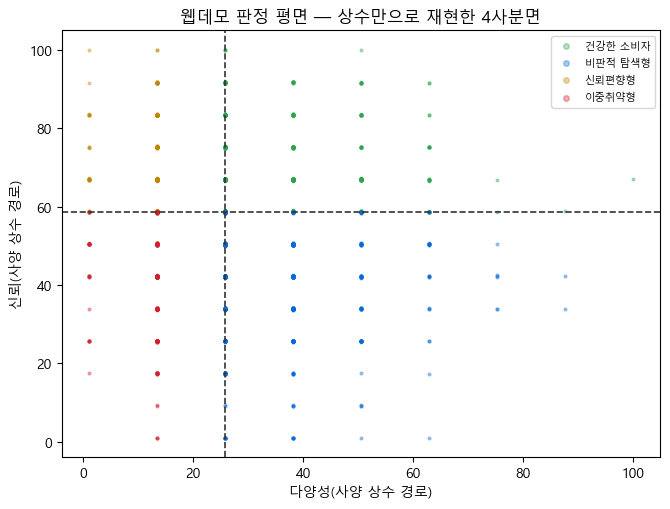

In [4]:
# 상수 경로(웹데모 시뮬레이션): SPEC의 숫자만 사용
t = SPEC["trust"]; d = SPEC["diversity"]
# 부분응답 처리: 응답한 문항의 z 평균 — SSOT 경로와 동일한 skipna 행평균
z_cols = pd.DataFrame({c: (sub[c] - t["item_mean"][c]) / t["item_std"][c] for c in CORE3})
raw_web = z_cols.mean(axis=1)
T_web = 1 + (raw_web - t["raw_min"]) / (t["raw_max"] - t["raw_min"]) * 99
D_web = 1 + (D_raw - d["richness_min"]) / (d["richness_max"] - d["richness_min"]) * 99

hi_t = T_web >= t["threshold_1_100"]; hi_d = D_web >= d["threshold_1_100"]
key = hi_t.map({True: "T", False: "F"}) + hi_d.map({True: "T", False: "F"})
persona_web = key.map(SPEC["quadrant_labels"])
persona_web[T_web.isna() | D_web.isna()] = np.nan

both = persona_ref.notna() & persona_web.notna()
match = float((persona_ref[both] == persona_web[both]).mean())
num_t = float((T_web - T_resp).abs().max())
num_d = float((D_web - D_resp).abs().max())
print(f"수치 일치: |T_web - T_ssot| max = {num_t:.2e} · |D_web - D_ssot| max = {num_d:.2e}")
print(f"판정 일치율: {match:.6%} ({int(both.sum()):,}명 대조)")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
rng = np.random.default_rng(7)
idx = persona_web.dropna().index
samp = rng.choice(idx, size=int(len(idx) * 0.02), replace=False)
COLORS = {"건강한 소비자": "#2da44e", "비판적 탐색형": "#0969da",
          "신뢰편향형": "#bf8700", "이중취약형": "#cf222e"}
for lab, c in COLORS.items():
    mm = persona_web.loc[samp] == lab
    ax.scatter(D_web.loc[samp][mm], T_web.loc[samp][mm], s=4, alpha=0.35, color=c, label=lab)
ax.axhline(t["threshold_1_100"], color="#333", lw=1.2, ls="--")
ax.axvline(d["threshold_1_100"], color="#333", lw=1.2, ls="--")
ax.set_xlabel("다양성(사양 상수 경로)"); ax.set_ylabel("신뢰(사양 상수 경로)")
ax.set_title("웹데모 판정 평면 — 상수만으로 재현한 4사분면")
ax.legend(fontsize=7.5, markerscale=2)
fig.tight_layout(); plt.show()

## **5. [실행] 사양 JSON export + 가상 사용자 데모**

사양을 [`web/diagnosis-spec.json`](../web/diagnosis-spec.json)으로 저장한다(웹데모의 SSOT — P6-C가 이 파일을 import). 이어 가상 사용자 3명으로 진단 흐름을 데모한다.

In [5]:
spec_path = ROOT / "web" / "diagnosis-spec.json"
spec_path.parent.mkdir(exist_ok=True)
spec_path.write_text(json.dumps(SPEC, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"사양 저장: {spec_path.relative_to(ROOT)} ({spec_path.stat().st_size/1024:.1f} KB)")

def diagnose(cred: dict, media_count: int):
    """SPEC 상수만으로 판정(웹데모 로직의 파이썬 데모)."""
    zz = [ (cred[c] - t["item_mean"][c]) / t["item_std"][c] for c in CORE3 ]
    T_ = 1 + (np.mean(zz) - t["raw_min"]) / (t["raw_max"] - t["raw_min"]) * 99
    D_ = 1 + (media_count - d["richness_min"]) / (d["richness_max"] - d["richness_min"]) * 99
    k = ("T" if T_ >= t["threshold_1_100"] else "F") + ("T" if D_ >= d["threshold_1_100"] else "F")
    lab = SPEC["quadrant_labels"][k]
    return lab, round(float(T_), 1), round(float(D_), 1)

demo_users = [
    ("TV만 보는 고신뢰 응답자", {"cred_fair": 4, "cred_professional": 4, "cred_accurate": 4}, 1),
    ("다채널 저신뢰 탐색가", {"cred_fair": 2, "cred_professional": 3, "cred_accurate": 2}, 6),
    ("평균적 이용자", {"cred_fair": 3, "cred_professional": 3, "cred_accurate": 3}, 3),
]
for name, cred, k in demo_users:
    lab, T_, D_ = diagnose(cred, k)
    print(f"  {name}: 신뢰 {T_} · 다양성 {D_} → [{lab}] — 처방: {SPEC['prescriptions'][lab]['rx']}")

사양 저장: web\diagnosis-spec.json (2.5 KB)
  TV만 보는 고신뢰 응답자: 신뢰 75.2 · 다양성 13.4 → [신뢰편향형] — 처방: 관심사 기반 신규 매체 1~2종 추가 제안(레퍼토리 확장)
  다채널 저신뢰 탐색가: 신뢰 33.9 · 다양성 75.2 → [비판적 탐색형] — 처방: 저신뢰의 근거 점검 도구(팩트체크 서비스) 안내
  평균적 이용자: 신뢰 50.5 · 다양성 38.1 → [비판적 탐색형] — 처방: 저신뢰의 근거 점검 도구(팩트체크 서비스) 안내


## **6. [입증] 검증 셀**

In [6]:
# (a) 수치 동일성 — 상수 경로 ≡ SSOT 함수 경로 (부동소수 오차 이내)
assert num_t < 1e-6 and num_d < 1e-6, (num_t, num_d)
print(f"(a) 지수 수치 동일(오차 < 1e-6) PASS")

# (b) 판정 전수 일치 — 90,996행 중 유효 전원
assert match == 1.0, match
assert int(both.sum()) == int(persona_ref.notna().sum())
print(f"(b) 판정 일치율 100% ({int(both.sum()):,}명) — 사양 이식 가능성 입증 PASS")

# (c) 사양 파일 라운드트립 — 저장본 재로드 = 메모리 사양
reloaded = json.loads(spec_path.read_text(encoding="utf-8"))
assert reloaded == json.loads(json.dumps(SPEC, ensure_ascii=False)), "spec 라운드트립 불일치"
print(f"(c) web/diagnosis-spec.json 라운드트립 일치 PASS")

# (d) 데모 판정의 방향 정합 — TV만 고신뢰 → 신뢰편향형 · 다채널 저신뢰 → 비판적 탐색형
assert diagnose({"cred_fair": 4, "cred_professional": 4, "cred_accurate": 4}, 1)[0] == "신뢰편향형"
assert diagnose({"cred_fair": 2, "cred_professional": 3, "cred_accurate": 2}, 6)[0] == "비판적 탐색형"
print("(d) 가상 사용자 판정 방향 정합 PASS")
print("\n검증 (a)~(d) 전부 PASS — 웹데모 사양 SSOT 확정")

(a) 지수 수치 동일(오차 < 1e-6) PASS
(b) 판정 일치율 100% (90,996명) — 사양 이식 가능성 입증 PASS
(c) web/diagnosis-spec.json 라운드트립 일치 PASS
(d) 가상 사용자 판정 방향 정합 PASS

검증 (a)~(d) 전부 PASS — 웹데모 사양 SSOT 확정


## **7. [실행] v1.1 확장 ① — pooled 분위수/CDF (상대 위치 lookup)**

결과 화면의 "기준선 대비 상대 위치" 표현용. 신뢰는 cred3 완답 5³=125개 조합의 도달 가능 점수를 전량 열거하고, 기준선(90,996행 `T_resp` 분포)에서 각 점수 미만/이하 비율을 lookup 테이블로 담는다. 다양성은 0~8 **이산 9값**이라 분위수 그리드가 무의미 — 누적분포(CDF) lookup을 채택한다. 웹은 이 테이블을 **조회만** 하고 재계산하지 않는다(로직 재정의 금지). 상대 위치는 자격규율상 "방향"으로만 서술한다.

In [7]:
from itertools import product

T_valid = T_resp.dropna()
D_valid = D_raw.dropna()

# 신뢰: 완답 125조합의 도달 가능 점수 전량 열거(중복 제거·정렬)
combo_scores = []
for vals in product(range(1, 6), repeat=3):
    zz = [(v - t["item_mean"][c]) / t["item_std"][c] for v, c in zip(vals, CORE3)]
    combo_scores.append(1 + (float(np.mean(zz)) - t["raw_min"]) / (t["raw_max"] - t["raw_min"]) * 99)
scores = sorted(set(round(s, 10) for s in combo_scores))
trust_pct_below = [float((T_valid < s).mean() * 100) for s in scores]
trust_pct_at_or_below = [float((T_valid <= s).mean() * 100) for s in scores]

rich_vals = list(range(0, 9))
div_pct_below = [float((D_valid < k).mean() * 100) for k in rich_vals]
div_pct_at_or_below = [float((D_valid <= k).mean() * 100) for k in rich_vals]

SPEC["baseline"] = {
    "n": int(len(panel)),
    "note": "상대 위치는 2016~2025 통합 기준선 대비 방향이며 절대 평가가 아님",
    "trust_percentiles": {"scores": scores, "pct_below": trust_pct_below,
                          "pct_at_or_below": trust_pct_at_or_below},
    "diversity_cdf": {"richness": rich_vals, "pct_below": div_pct_below,
                      "pct_at_or_below": div_pct_at_or_below},
}

# 가상 사용자 3명의 분위수 조회값 — 웹 verify-diagnosis.mjs의 기준값
def _lookup_trust_pct(T_):
    i = int(np.argmin([abs(s - T_) for s in scores]))
    return trust_pct_below[i]

for name, cred, k in demo_users:
    zz = [(cred[c] - t["item_mean"][c]) / t["item_std"][c] for c in CORE3]
    T_full = 1 + (float(np.mean(zz)) - t["raw_min"]) / (t["raw_max"] - t["raw_min"]) * 99
    print(f"  {name}: trust_pct_below={_lookup_trust_pct(T_full)!r} · div_pct_below={div_pct_below[k]!r}")
print(f"신뢰 도달 가능 점수 {len(scores)}개 · 다양성 CDF 9값 — SPEC['baseline'] 추가")

  TV만 보는 고신뢰 응답자: trust_pct_below=82.12778583674007 · div_pct_below=3.8639061057628905
  다채널 저신뢰 탐색가: trust_pct_below=17.482087124708777 · div_pct_below=99.16699635148798
  평균적 이용자: trust_pct_below=33.90918282122291 · div_pct_below=69.27227570442656
신뢰 도달 가능 점수 125개 · 다양성 CDF 9값 — SPEC['baseline'] 추가


## **8. [실행] v1.1 확장 ② — 유형 프로파일 카드 (08 방향 assert 재검증 후 조립)**

자격규율: 카드 문구는 **방향 문자열만** — 절대 수치(%·세·점)를 넣지 않고 regex assert로 기계 봉인한다. 조립 전에 `08` §6의 (a)~(c) 방향 assert를 동일 가중(`wt_year_eq`) 집계로 재실행해, **통과할 때만** facts를 만든다 — 문구 하나하나가 검증 셀에 얹힌다.

In [8]:
import re

W = panel["wt_year_eq"]
ORDER = ["건강한 소비자", "비판적 탐색형", "신뢰편향형", "이중취약형"]
USE8 = list(hz.FIXED_POOL8); NEW3 = list(hz.USE_NEW_MEDIA)
KR = {"use_paper": "종이신문", "use_magazine": "잡지", "use_tv": "TV", "use_radio": "라디오",
      "use_internet": "인터넷", "use_messenger": "메신저", "use_sns": "SNS", "use_video": "동영상",
      "use_short": "숏폼", "use_ott": "OTT", "use_ai": "AI"}
mm_new = panel["year"] >= 2023
mat = []
for lab in ORDER:
    mm = persona_ref == lab
    row = [nf.wmean(pd.to_numeric(panel[c], errors="coerce")[mm], W[mm]) * 100 for c in USE8]
    row += [nf.wmean(pd.to_numeric(panel[c], errors="coerce")[mm & mm_new], W[mm & mm_new]) * 100
            for c in NEW3]
    mat.append(row)
prof = pd.DataFrame(mat, index=ORDER, columns=[KR[c] for c in USE8 + NEW3])
age = pd.to_numeric(panel["age"], errors="coerce")
mean_age = {lab: nf.wmean(age[persona_ref == lab], W[persona_ref == lab]) for lab in ORDER}

# 08 §6 (a)~(c) 방향 재검증 — 통과해야만 facts 조립
for lab in ["신뢰편향형", "이중취약형"]:
    assert prof.loc[lab].idxmax() == "TV", prof.loc[lab].idxmax()
for lo_lab in ["신뢰편향형", "이중취약형"]:
    for hi_lab in ["건강한 소비자", "비판적 탐색형"]:
        assert mean_age[lo_lab] > mean_age[hi_lab], (lo_lab, hi_lab)
for med in ["숏폼", "OTT"]:
    lo = max(prof.loc["신뢰편향형", med], prof.loc["이중취약형", med])
    hi = min(prof.loc["건강한 소비자", med], prof.loc["비판적 탐색형", med])
    assert lo <= hi / 3, (med, lo, hi)
rich_mean = {lab: nf.wmean(D_raw[persona_ref == lab], W[persona_ref == lab]) for lab in ORDER}
assert min(rich_mean["건강한 소비자"], rich_mean["비판적 탐색형"]) > \
       max(rich_mean["신뢰편향형"], rich_mean["이중취약형"])
print("08 §6 (a)~(c) + 레퍼토리 방향 재검증 PASS — facts 조립")

SPEC["profiles"] = {
    "신뢰편향형": {"facts": [
        {"text": "이 유형이 가장 많이 이용하는 매체는 TV입니다(방향)", "evidence": "notebooks/08 §6(a)"},
        {"text": "고다양 유형 대비 평균연령이 높은 방향(전 쌍 비교 일관)", "evidence": "notebooks/08 §6(b)"},
        {"text": "숏폼·OTT 같은 신설매체 이용은 고다양 유형의 1/3 이하 수준(방향)", "evidence": "notebooks/08 §6(c)"},
    ]},
    "이중취약형": {"facts": [
        {"text": "가장 많이 이용하는 매체는 TV — 채널이 좁은 방향", "evidence": "notebooks/08 §6(a)"},
        {"text": "고다양 유형 대비 평균연령이 높은 방향(전 쌍 비교 일관)", "evidence": "notebooks/08 §6(b)"},
        {"text": "디지털 전환(숏폼·OTT)이 비껴가는 방향 — 고다양 유형의 1/3 이하", "evidence": "notebooks/08 §6(c)"},
    ]},
    "건강한 소비자": {"facts": [
        {"text": "네 유형 중 뉴스 건강 지수(NCHI)가 가장 높은 유형(방향)", "evidence": "notebooks/05 §2"},
        {"text": "TV와 인터넷을 축으로 넓은 매체 레퍼토리를 가진 방향", "evidence": "notebooks/08 §4"},
    ]},
    "비판적 탐색형": {"facts": [
        {"text": "가장 넓은 매체 레퍼토리 방향 — 다양한 채널을 오가며 탐색", "evidence": "notebooks/05 §2·08 §4"},
        {"text": "신뢰 인식은 낮지만 이용 폭은 넓은 방향 — 교차 확인형 소비", "evidence": "notebooks/08 §4"},
    ]},
}
for lab, pr in SPEC["profiles"].items():
    for f in pr["facts"]:
        assert not re.search(r"\d+(\.\d+)?\s*(%|세|점)", f["text"]), f["text"]
print("facts 절대 수치 미포함(%·세·점) regex 봉인 PASS")

08 §6 (a)~(c) + 레퍼토리 방향 재검증 PASS — facts 조립
facts 절대 수치 미포함(%·세·점) regex 봉인 PASS


## **9. [실행] v1.1 확장 ③ — 경계 밴드 (임계 부근 판정 고지)**

`04` §6이 입증한 임계 민감도(임계 이동 시 구성비 급변)에 따라, 판정이 임계 부근일 때 "문항/매체 1개 차이로 유형이 바뀔 수 있다"를 고지한다. 밴드 반경 = 입력 최소 변화(±1)가 만드는 최대 점수 변화 — 신뢰 = max_c 99/(3·std_c·(raw_max−raw_min)), 다양성 = 99/8. **입증**: 1,125개(125조합×9매체수) 입력 전수에서 ±1 섭동으로 판정이 뒤집히는 입력이 전부 밴드 내임을 brute-force assert(밴드 ⊇ 뒤집힘 집합).

In [9]:
trust_half_width = max(99 / (3 * t["item_std"][c] * (t["raw_max"] - t["raw_min"])) for c in CORE3)
diversity_half_width = 99 / (d["richness_max"] - d["richness_min"])
SPEC["boundary_band"] = {
    "trust_half_width_1_100": float(trust_half_width),
    "diversity_half_width_1_100": float(diversity_half_width),
    "rule": "abs(score - threshold) <= half_width 이면 임계 부근 판정 안내",
}

def _score(cred_vals, k):
    zz = [(v - t["item_mean"][c]) / t["item_std"][c] for v, c in zip(cred_vals, CORE3)]
    T_ = 1 + (float(np.mean(zz)) - t["raw_min"]) / (t["raw_max"] - t["raw_min"]) * 99
    D_ = 1 + (k - d["richness_min"]) / (d["richness_max"] - d["richness_min"]) * 99
    return T_, D_

def _persona_of(T_, D_):
    key = ("T" if T_ >= t["threshold_1_100"] else "F") + ("T" if D_ >= d["threshold_1_100"] else "F")
    return SPEC["quadrant_labels"][key]

n_flip_t = n_flip_d = 0
for vals in product(range(1, 6), repeat=3):
    for k in range(0, 9):
        T0, D0 = _score(vals, k)
        p0 = _persona_of(T0, D0)
        for i in range(3):                      # 신뢰 문항 ±1 섭동
            for dv in (-1, 1):
                v2 = list(vals); v2[i] += dv
                if not 1 <= v2[i] <= 5:
                    continue
                if _persona_of(*_score(v2, k)) != p0:
                    n_flip_t += 1
                    assert abs(T0 - t["threshold_1_100"]) <= trust_half_width + 1e-9, (vals, k)
        for dk in (-1, 1):                      # 매체 ±1 섭동
            if not 0 <= k + dk <= 8:
                continue
            if _persona_of(*_score(vals, k + dk)) != p0:
                n_flip_d += 1
                assert abs(D0 - d["threshold_1_100"]) <= diversity_half_width + 1e-9, (vals, k)
print(f"경계 밴드: 신뢰 ±{trust_half_width:.4f} · 다양성 ±{diversity_half_width:.3f}")
print(f"뒤집힘 입력 전수 밴드 내 확인 — 신뢰 섭동 {n_flip_t}건 · 매체 섭동 {n_flip_d}건 PASS")

경계 밴드: 신뢰 ±8.4367 · 다양성 ±12.375
뒤집힘 입력 전수 밴드 내 확인 — 신뢰 섭동 810건 · 매체 섭동 250건 PASS


## **10. [입증] v1.1 검증 + 재export**

In [10]:
# (e) 분위수/CDF 무결성 — 정렬·단조·범위·중앙값 정합
b = SPEC["baseline"]; tp = b["trust_percentiles"]; dc = b["diversity_cdf"]
assert all(tp["scores"][i] < tp["scores"][i + 1] for i in range(len(tp["scores"]) - 1))
assert len(tp["scores"]) <= 125
for seq in (tp["pct_below"], tp["pct_at_or_below"], dc["pct_below"], dc["pct_at_or_below"]):
    assert all(0 <= v <= 100 for v in seq)
    assert all(seq[i] <= seq[i + 1] + 1e-12 for i in range(len(seq) - 1))
assert abs(dc["pct_at_or_below"][-1] - 100) < 1e-9
thr_t = t["threshold_1_100"]; thr_d = d["threshold_1_100"]
assert float((T_valid < thr_t).mean() * 100) <= 50 <= float((T_valid <= thr_t).mean() * 100)
assert dc["pct_below"][2] <= 50 <= dc["pct_at_or_below"][2]  # 다양성 임계 = richness 2
print("(e) 분위수/CDF 무결성 + 중앙값 정합 PASS")

# (f) 경계 밴드 폭 sanity
bb = SPEC["boundary_band"]
assert 0 < bb["trust_half_width_1_100"] < 25 and 0 < bb["diversity_half_width_1_100"] < 25
print("(f) 경계 밴드 폭 sanity PASS")

# (g) v1.0 키 불변 — §6 (c)의 저장본(reloaded)과 공통 키 동일 → §4 전수 일치 검증 유효 유지
for key in ["inputs", "trust", "diversity", "quadrant_labels", "prescriptions"]:
    assert reloaded[key] == json.loads(json.dumps(SPEC[key], ensure_ascii=False)), key
print("(g) v1.0 키(판정 상수) 불변 PASS — §4 전수 일치 그대로 유효")

# (h) v1.1 재export + 라운드트립
SPEC["version"] = "1.1 (P6-C, notebooks/09)"
spec_path.write_text(json.dumps(SPEC, ensure_ascii=False, indent=2), encoding="utf-8")
rel2 = json.loads(spec_path.read_text(encoding="utf-8"))
assert rel2 == json.loads(json.dumps(SPEC, ensure_ascii=False))
assert all(key in rel2 for key in ["baseline", "boundary_band", "profiles"])
assert all(len(rel2["profiles"][lab]["facts"]) > 0 for lab in rel2["quadrant_labels"].values())
print(f"(h) v1.1 재export PASS ({spec_path.stat().st_size / 1024:.1f} KB)")
print("\nv1.1 확장 검증 (e)~(h) 전부 PASS — 웹데모 사양 v1.1 확정")

(e) 분위수/CDF 무결성 + 중앙값 정합 PASS
(f) 경계 밴드 폭 sanity PASS
(g) v1.0 키(판정 상수) 불변 PASS — §4 전수 일치 그대로 유효
(h) v1.1 재export PASS (15.3 KB)

v1.1 확장 검증 (e)~(h) 전부 PASS — 웹데모 사양 v1.1 확정


## **11. 종합 — 웹데모로 넘어갈 준비가 끝났다**

### **연구질문 답**

- **Q1** — `persona_quadrant`의 실제 입력이 cred3+8매체뿐이므로 11문항이 필요충분(DB①). 버린 문항들은 각자 검증된 배제 근거를 가진다(press_free `18`, 단일문항 프록시 `17`, 일수·빈도 `06` R3).
- **Q2** — 필요한 상수는 문항별 pooled 평균·표준편차(3×2), raw min/max, richness 범위, 임계 2개 — 전부 `web/diagnosis-spec.json`에 담겼고, 상수 경로의 재판정이 파이프라인과 **90,996행 전수 일치**(§4·§6 (b)).
- **Q3** — 처방 문구는 `08`의 assert된 프로파일(TV 편중·고령 집중·신설매체 0)에 1:1로 얹혔다(§3) — 절대 수치는 쓰지 않는다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 판정 상수 도출 | 사양 확정 |
| 3 | 처방 매핑(근거 연결) | 표 확정 |
| 4 | 전수 재판정 [시각화] | **100% 일치** |
| 5 | JSON export + 데모 | spec 저장 |
| 6 | 일괄 assert | **PASS** |
| 7 | v1.1 분위수/CDF lookup | baseline |
| 8 | v1.1 프로파일 카드(08 재검증) | profiles |
| 9 | v1.1 경계 밴드(전수 입증) | boundary_band |
| 10 | v1.1 일괄 assert + 재export | **PASS** |

### **v1.1 확장 (P6-C)**

웹데모 결과 화면 요구가 사양을 역으로 확장시켰다: **baseline**(pooled 분위수/CDF — "기준선 대비 상대 위치" lookup, §7), **profiles**(08 방향 assert를 재검증한 뒤에만 조립되는 유형 카드 facts — 절대 수치 regex 봉인, §8), **boundary_band**(±1 섭동 전수 입증의 임계 부근 고지, §9). v1.0 판정 상수는 불변(§10 (g))이므로 §4의 90,996행 전수 일치는 그대로 유효하다.

### **다음(P6-C 웹데모 구현 지시서)**

1. Next.js 15 정적 페이지에서 `web/diagnosis-spec.json` import → 11문항 폼 → §5 `diagnose` 로직의 JS 이식(상수 연산뿐이라 수 줄).
2. 결과 화면: 유형 + 4사분면 위치 + 상대 위치(§7) + 프로파일 카드(§8) + 경계 밴드 고지(§9) + 처방 문구(§3) → **F9 스크린샷 캡처** → manuscript 그림 10 교체 → `32` 재실행(최종 PDF).